In [1]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin
import os
from tqdm import tqdm
from joblib import Parallel, delayed

In [2]:
#function
#ABS
def gr_L(T_l, A_l, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
    check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    max_err = np.max(np.abs(check))

    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD(H_q, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, N, E, eta=3e-6):
    d = H_q.shape[0]
    
    # 构造复能量矩阵 (简化的写法，等价于你的 EI_gai)
    EI_gai = (E + 1j * eta) * np.eye(d, dtype=complex)

    # 1. 计算左引线自能
    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    # 2. 计算右引线自能
    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    # ==========================================
    # 核心修改：使用 RGF 算法提取 G_00 和 G_01
    # ==========================================
    ALR = EI_gai - H_q
    V = T_21
    
    # 3. Right-to-Left 扫掠：只记录向右连通的等效格林函数 gR
    gR = np.zeros((N, d, d), dtype=complex)
    gR[N-1] = np.linalg.inv(ALR - Sigma_R)
    
    # 从 N-2 往 1 递推，把右侧的物理效应不断折叠为等效自能
    for n in range(N-2, 0, -1):
        gR[n] = np.linalg.inv(ALR - V @ gR[n+1] @ V.conj().T)
        
    # 4. 算出真正的左上角 4x4 格林函数 G_00 (原 G_DD_r[0:4, 0:4])
    # 在最左侧 n=0 处，加上左引线的自能 Sigma_L
    G_00 = np.linalg.inv(ALR - V @ gR[1] @ V.conj().T - Sigma_L)
    
    # 5. 算出左上角右侧相邻的 4x4 非对角块 G_01 (原 G_DD_r[0:4, 4:8])
    # 根据 Dyson 方程，G_01 = G_00 * V_01 * gR_1
    #G_01 = G_00 @ V @ gR[1]

    # 返回你需要的结果 (去掉了庞大无用的 A_DD)
    return G_00, G_00, Sigma_R, Sigma_L

def bufeng(G_00):
    d = H_q.shape[0]
    yigeshu=np.trace(G_00)
    return -np.imag(yigeshu)/np.pi

def find_peaks_fmin(A_of_E, E_min, E_max, N_guess=11, xtol=1e-6, ftol=1e-6, round_digits=6):

    E_guesses = np.linspace(E_min, E_max, N_guess)
    peak_list = []

    for E0 in E_guesses:
        r = fmin(lambda E: -A_of_E(E), E0, disp=False, xtol=xtol, ftol=ftol)
        peak_list.append(r[0])

    peak_list = np.unique(np.round(peak_list, round_digits))
    return peak_list


#current
def Gr_DD_MS(H_q, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, N, wn):
    d = H_q.shape[0]
    
    # 构造松原频率复能量矩阵
    # 假设外部已经定义了 s0 = np.eye(2, dtype=complex)
    EI_gai =  np.eye(d, dtype=complex) * (1j * wn)

    # 1. 计算左引线自能
    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    # 2. 计算右引线自能
    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    # ==========================================
    # 核心修改：使用 RGF 算法提取 Matsubara G_00, G_01 和 G_10
    # ==========================================
    ALR = EI_gai - H_q
    V = T_21

    # 特殊情况防错：如果 N=1，只有1个格点
    if N == 1:
        G_00 = np.linalg.inv(ALR - Sigma_L - Sigma_R)
        G_01 = np.zeros((d, d), dtype=complex)
        G_10 = np.zeros((d, d), dtype=complex)
        return G_00, G_01, G_10, Sigma_R, Sigma_L

    # 3. Right-to-Left 扫掠：只记录向右连通的等效松原格林函数 gR
    gR = np.zeros((N, d, d), dtype=complex)
    gR[N-1] = np.linalg.inv(ALR - Sigma_R)
    
    # 从 N-2 往 1 递推，把右侧的物理效应不断折叠为等效自能
    for n in range(N-2, 0, -1):
        gR[n] = np.linalg.inv(ALR - V @ gR[n+1] @ V.conj().T)
        
    # 4. 算出真正的左上角 4x4 松原格林函数 G_00
    # 在最左侧 n=0 处，加上左引线的自能 Sigma_L
    G_00 = np.linalg.inv(ALR - V @ gR[1] @ V.conj().T - Sigma_L)
    
    # 5. 算出右侧相邻的非对角块 G_01
    # 公式: G_{0,1} = G_{0,0} * V * gR_1
    G_01 = G_00 @ V @ gR[1]

    # 6. 算出下方相邻的非对角块 G_10
    # 公式: G_{1,0} = gR_1 * V^\dagger * G_{0,0}
    G_10 = gR[1] @ V.conj().T @ G_00

    # 返回优化后的结果 
    return G_00, G_01, G_10, Sigma_R, Sigma_L

def J_wn(G_01, G_10, T_21):
    d = T_21.shape[0]
    G_q_q1 = G_01
    G_q1_q = G_10
    Jmat = T_21.conj().T @ G_10 - G_01 @ T_21
    diag_J = np.diag(Jmat)
    
    selected_trace = np.sum(diag_J.reshape(-1, 4)[:, :2])

    return selected_trace * (-1j) * KBT * (1)#/delta

def matsubara_list(shumu):
    n_max =  shumu
    n_vals = np.arange(-n_max, n_max+1 )
    wn = (2 * n_vals + 1) * np.pi * KBT

    return wn.tolist()

def J_matsubara_sum(shumu,H_q, H_l, H_r,T_21, T_LD, T_l, T_RD, T_r,N):
    wn_list = matsubara_list(shumu)
    J_sum = 0.0 
    for wn in wn_list:
        _, G_01, G_10, _, _ = Gr_DD_MS(
            H_q, H_l, H_r,
            T_21, T_LD, T_l, T_RD, T_r,
            N, wn
        )

        J_sum += np.real(J_wn(G_01, G_10, T_21))
    return (J_sum)

def J_of_phi(phi):
    H_l = H_onstie(m,B,a   ,uS_set,Delta,0,    yshumu,4,    A)
    H_q = H_onstie(m,B,a   ,uN_set,0,0,    yshumu,4,    A)
    H_r =  H_onstie(m,B,a   ,uS_set,Delta,-phi,    yshumu,4,    A)
    Jphi = J_matsubara_sum(shumu,H_q, H_l, H_r,T_21, T_LD, T_l, T_RD, T_r,N)
    return Jphi

def find_J_extreme_fmin(phi_min=0*np.pi, phi_max=2*np.pi,
                       N_guess=4, xtol=1e-4, ftol=1e-4,
                       round_digits=6):

    phi_guesses = np.linspace(phi_min, phi_max, N_guess)

    max_list = []
    min_list = []

    for phi0 in phi_guesses:

        # 最大值
        rmax = fmin(lambda phi: -J_of_phi(phi), phi0,
                    disp=False, xtol=xtol, ftol=ftol)
        max_list.append(rmax[0])

        # 最小值
        rmin = fmin(lambda phi: J_of_phi(phi), phi0,
                    disp=False, xtol=xtol, ftol=ftol)
        min_list.append(rmin[0])

    phi_max_list = np.unique(np.round(max_list, round_digits))
    phi_min_list = np.unique(np.round(min_list, round_digits))

    J_max = max(J_of_phi(phi) for phi in phi_max_list)
    J_min = min(J_of_phi(phi) for phi in phi_min_list)


    J_max = -np.inf
    phi_at_Jmax = None

    for phi in phi_max_list:
        val = J_of_phi(phi)
        if val > J_max:
            J_max = val
            phi_at_Jmax = phi

    J_min = np.inf
    phi_at_Jmin = None

    for phi in phi_min_list:
        val = J_of_phi(phi)
        if val < J_min:
            J_min = val
            phi_at_Jmin = phi

    yinzi =abs(abs(J_max) - abs(J_min)) / (abs(J_max) + abs(J_min))

    return J_max, phi_at_Jmax/np.pi, J_min, phi_at_Jmin/np.pi, yinzi


In [15]:
#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def h_k(m,B,a):
    return (m-4*B/(a**2))*sz

def h_x(B,a,A):
    return (B/(a**2))*sz-(1j/2)*A*sx

def h_y(B,a,A):
    return (B/(a**2))*sz-(1j/2)*A*sy

def h_onstie(m,B,a   ,u,Delta,chaodaojiao):
    HX_block=h_k(m,B,a)-u*s0
    Delta_X= 1j *Delta * np.exp(1j*chaodaojiao) *  sy
    return np.block([
        [ HX_block,        Delta_X       ],
        [ Delta_X.conj().T, -HX_block.conj() ]
    ])

def t_x(B,a,A):
    TX_block=h_x(B,a,A)
    ling_X=np.zeros((2,2))
    return np.block([
        [ TX_block,        ling_X       ],
        [ ling_X.conj().T, -TX_block.conj() ]
    ])

def t_y(B,a,A):
    TX_block=h_y(B,a,A)
    ling_X=np.zeros((2,2))
    return np.block([
        [ TX_block,        ling_X       ],
        [ ling_X.conj().T, -TX_block.conj() ]
    ])

def H_onstie(m,B,a   ,u_set,Delta,chaodaojiao,    yshumu,Nd,    A):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(yshumu)] for _ in range(yshumu)]

    for i in range(yshumu):
        H[i][i]=h_onstie(m,B,a   ,u_set[i],Delta,chaodaojiao)

        if i < yshumu-1:
            H[i][i+1] = t_y(B,a,A)

        if i > 0:
            H[i][i-1] = t_y(B,a,A).conj().T
    
    H = np.block(H)
    return H

def H_hop(B,a,A,   yshumu,Nd):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(yshumu)] for _ in range(yshumu)]

    for i in range(yshumu):
        H[i][i]=t_x(B,a,A)

    #
    H = np.block(H)
    return H

m=0.5
A=1  
B=1  

delta=0.1
chaodaojiao=0
T_Tc=1e-4
Delta = delta* np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))
KBT=2 * delta * T_Tc / 3.5
shumu=401


a=1
N=2
yshumu=11

uN=0
uS=0.3
#uS=1


#Ey = 0.0035/yshumu*0.9#
Ey= 0.007/yshumu*1  
#Ey=0.0035/10
#Ey=0.003/100
uN_set = []
for i in range(yshumu):
    uN_set.append(uN- Ey*0* (i - yshumu/2))
uS_set=[]
for i in range(yshumu):
    uS_set.append(uS - Ey *1* (i - yshumu/2))
#uS_set=[]
#for i in range(Ny):
#    uS_set.append(uS)
#print(uN_set[99])
#print(uS_set[99])

H_q= H_onstie(m,B,a   ,uN_set,0,0,    yshumu,4,    A)
T_21= H_hop(B,a,A,   yshumu,4)#.conj().T

H_l= H_onstie(m,B,a   ,uS_set,Delta,0,    yshumu,4,    A)
T_l= H_hop(B,a,A,   yshumu,4)#.conj().T

H_r= H_onstie(m,B,a   ,uS_set,Delta,-chaodaojiao,    yshumu,4,    A)
T_r= H_hop(B,a,A,   yshumu,4).conj().T

T_LD=H_hop(B,a,A,   yshumu,4).conj().T
T_RD=H_hop(B,a,A,   yshumu,4)

#print(H_q.shape)

Calculating Bands: 100%|██████████| 1001/1001 [00:00<00:00, 12818.55it/s]


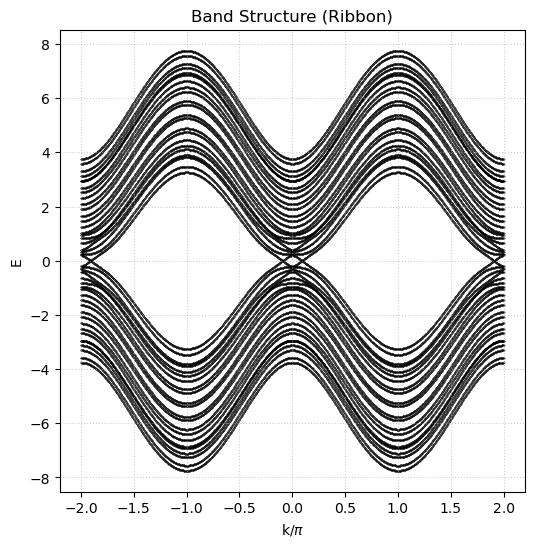

In [16]:
# 两边能带
ks1 = np.linspace(-2*np.pi, 2*np.pi, 1001)
def Hk(k, H, T):
    # H(k) = H_onsite + T * exp(-ik) + T.conj().T * exp(ik)
    return H + T * np.exp(-1j * k) + T.conj().T * np.exp(1j * k)

energies1 = []
# 使用 tqdm 显示进度条
for k in tqdm(ks1, desc="Calculating Bands"):
    H_k = Hk(k, H_r, T_r)
    # 使用 eigvalsh 专门针对 Hermitian 矩阵进行快速求解
    evals1 = np.linalg.eigvalsh(H_k)
    energies1.append(evals1)

energies1 = np.array(energies1)


# 绘图：x 轴显示 kx，y 轴显示 E
plt.figure(figsize=(6, 6))

for i in range(energies1.shape[1]):
    plt.scatter(ks1/np.pi, energies1[:, i], color='black', s=0.1)

#plt.ylim(-0.5,0.5)
#plt.xlim(-1,1)
plt.xlabel(r'k/$\pi$')
plt.ylabel('E')
plt.title('Band Structure (Ribbon)')
plt.grid(True, linestyle=':', alpha=0.6)

Calculating Bands: 100%|██████████| 2001/2001 [00:00<00:00, 15036.85it/s]


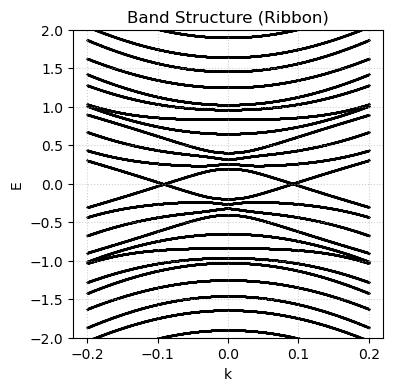

In [17]:
# 两边能带
ks1 = np.linspace(-0.2*np.pi, 0.2*np.pi, 2001)
def Hk(k, H, T):
    # H(k) = H_onsite + T * exp(-ik) + T.conj().T * exp(ik)
    return H + T * np.exp(-1j * k) + T.conj().T * np.exp(1j * k)

energies1 = []
# 使用 tqdm 显示进度条
for k in tqdm(ks1, desc="Calculating Bands"):
    H_k = Hk(k, H_r, T_r)
    # 使用 eigvalsh 专门针对 Hermitian 矩阵进行快速求解
    evals1 = np.linalg.eigvalsh(H_k)
    energies1.append(evals1)

energies1 = np.array(energies1)


# 绘图：x 轴显示 kx，y 轴显示 E
plt.figure(figsize=(4, 4))

for i in range(energies1.shape[1]):
    plt.scatter(ks1/np.pi, energies1[:, i], color='black', s=0.1)

plt.ylim(-2,2)
#plt.ylim(-0.04,0.04)
#plt.xlim(-1,1)
#plt.xlim(-0.04/np.pi,0.04/np.pi)
plt.xlabel(r'k')#/$\pi$')
plt.ylabel('E')
plt.title('Band Structure (Ribbon)')
plt.grid(True, linestyle=':', alpha=0.6)

Calculating Bands: 100%|██████████| 2001/2001 [00:00<00:00, 14872.36it/s]


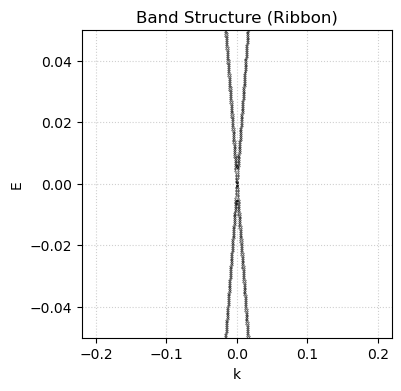

In [30]:
# 两边能带
ks1 = np.linspace(-0.2*np.pi, 0.2*np.pi, 2001)
def Hk(k, H, T):
    # H(k) = H_onsite + T * exp(-ik) + T.conj().T * exp(ik)
    return H + T * np.exp(-1j * k) + T.conj().T * np.exp(1j * k)

energies1 = []
# 使用 tqdm 显示进度条
for k in tqdm(ks1, desc="Calculating Bands"):
    H_k = Hk(k, H_r, T_r)
    # 使用 eigvalsh 专门针对 Hermitian 矩阵进行快速求解
    evals1 = np.linalg.eigvalsh(H_k)
    energies1.append(evals1)

energies1 = np.array(energies1)


# 绘图：x 轴显示 kx，y 轴显示 E
plt.figure(figsize=(4, 4))

for i in range(energies1.shape[1]):
    plt.scatter(ks1/np.pi, energies1[:, i], color='black', s=0.1)

plt.ylim(-0.05,0.05)
#plt.ylim(-0.04,0.04)
#plt.xlim(-1,1)
#plt.xlim(-0.04/np.pi,0.04/np.pi)
plt.xlabel(r'k')#/$\pi$')
plt.ylabel('E')
plt.title('Band Structure (Ribbon)')
plt.grid(True, linestyle=':', alpha=0.6)

Calculating Bands: 100%|██████████| 1001/1001 [00:00<00:00, 14938.83it/s]


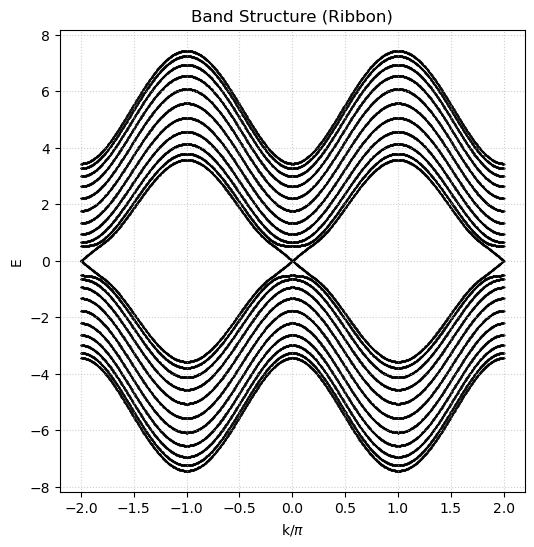

In [6]:
# 中间能带
ks = np.linspace(-2*np.pi, 2*np.pi, 1001)
#ks = np.linspace(-2*np.pi, 2*np.pi, 101)
def Hk(k, H, T):
    # H(k) = H_onsite + T * exp(-ik) + T.conj().T * exp(ik)
    return H + T * np.exp(-1j * k) + T.conj().T * np.exp(1j * k)

energies = []
# 使用 tqdm 显示进度条
for k in tqdm(ks, desc="Calculating Bands"):
    H_k = Hk(k, H_q, T_21)
    # 使用 eigvalsh 专门针对 Hermitian 矩阵进行快速求解
    evals = np.linalg.eigvalsh(H_k)
    energies.append(evals)

energies = np.array(energies)

# 绘图：x 轴显示 kx，y 轴显示 E
plt.figure(figsize=(6, 6))

for i in range(energies.shape[1]):
    plt.scatter(ks/np.pi, energies[:, i], color='black', s=0.1)

#plt.ylim(-0.5,0.5)
plt.xlabel(r'k/$\pi$')
plt.ylabel('E')
plt.title('Band Structure (Ribbon)')
plt.grid(True, linestyle=':', alpha=0.6)
#plt.savefig('band_structure.png')

Calculating Bands: 100%|██████████| 1001/1001 [00:00<00:00, 15166.83it/s]


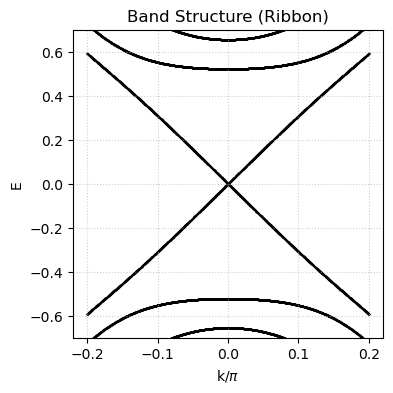

In [7]:
# 中间能带
#ks = np.linspace(-0.04, 0.04, 101)
ks = np.linspace(-0.2*np.pi, 0.2*np.pi, 1001)
def Hk(k, H, T):
    # H(k) = H_onsite + T * exp(-ik) + T.conj().T * exp(ik)
    return H + T * np.exp(-1j * k) + T.conj().T * np.exp(1j * k)

energies = []
# 使用 tqdm 显示进度条
for k in tqdm(ks, desc="Calculating Bands"):
    H_k = Hk(k, H_q, T_21)
    # 使用 eigvalsh 专门针对 Hermitian 矩阵进行快速求解
    evals = np.linalg.eigvalsh(H_k)
    energies.append(evals)

energies = np.array(energies)

# 绘图：x 轴显示 kx，y 轴显示 E
plt.figure(figsize=(4, 4))

for i in range(energies.shape[1]):
    plt.scatter(ks/np.pi, energies[:, i], color='black', s=0.1)

plt.ylim(-0.7,0.7)
plt.xlabel(r'k/$\pi$')
plt.ylabel('E')
#plt.ylim(-0.04,0.04)
#plt.xlim(-1,1)
#plt.xlim(-0.2/np.pi,0.2/np.pi)
plt.title('Band Structure (Ribbon)')
plt.grid(True, linestyle=':', alpha=0.6)
#plt.savefig('band_structure.png')

In [8]:
#ABS——态密度扫描
shangxia=0.1

num_ef = 50
efmin = -delta*shangxia
efmax = delta*shangxia
def_ = (efmax - efmin) / num_ef
num_phi = 50
phi_min = 0
phi_max = 2 * np.pi
dphi = (phi_max - phi_min) / num_phi

# Initialize grids
ef_plot = np.zeros(num_ef + 1)
phi_plot = np.zeros(num_phi + 1)
ABS = np.zeros((num_ef + 1, num_phi + 1))

for jj in range(num_ef + 1):
    ef = efmin + def_ * jj
    ef_plot[jj] = ef
    for ii in range(num_phi + 1):
        phi = phi_min + dphi * ii
        phi_plot[ii] = phi / np.pi
        
        # Update Delta and H_l, H_r based on phi
        H_r = H_onstie(m,B,a   ,uS_set,Delta,-phi,    yshumu,4,    A)
        
        # Compute G_DD_r
        G_00, _, _, _ = Gr_DD(
            H_q, H_l, H_r,
            T_21, T_LD, T_l, T_RD, T_r,
            N, ef
        )
        
        # Compute ABS (bufeng)
        ABS[jj, ii] = bufeng(G_00)



In [9]:
# ==========================================
# 1. 初始化网格与参数
# ==========================================
shangxia = 0.05
num_ef = 100
efmin = -delta * shangxia  # 确保 delta 在外部已经定义
efmax = delta * shangxia
def_ = (efmax - efmin) / num_ef

num_phi = 100
phi_min = 0
phi_max = 2 * np.pi
dphi = (phi_max - phi_min) / num_phi

# 初始化存储矩阵和画图坐标系
ef_plot = np.zeros(num_ef + 1)
phi_plot = np.zeros(num_phi + 1)
ABS = np.zeros((num_ef + 1, num_phi + 1))

# 预先构建好绘图用的坐标轴数组
for jj in range(num_ef + 1):
    ef_plot[jj] = efmin + def_ * jj
for ii in range(num_phi + 1):
    phi_plot[ii] = (phi_min + dphi * ii) / np.pi

# ==========================================
# 2. 任务展平：生成所有 2601 个任务的坐标
# ==========================================
tasks = []
for jj in range(num_ef + 1):
    ef = efmin + def_ * jj
    for ii in range(num_phi + 1):
        phi = phi_min + dphi * ii
        # 把网格的索引(jj, ii)和对应的物理量(ef, phi)打包起来
        tasks.append((jj, ii, ef, phi))

# ==========================================
# 3. 定义单点独立计算函数 (必须包含所有依赖变量)
# ==========================================
def compute_abs_point(jj, ii, ef, phi, m, B, a, uS_set, Delta, yshumu, A, H_q, H_l, T_21, T_LD, T_l, T_RD, T_r, N):
    """
    计算特定 (ef, phi) 下的态密度，并一并返回其在矩阵中的索引 (jj, ii)
    """
    # 根据当前 phi 更新右电极哈密顿量
    H_r_curr = H_onstie(m, B, a, uS_set, Delta, -phi, yshumu, 4, A)
    
    # 计算推迟格林函数 G_DD_r
    G_00, _, _, _ = Gr_DD(H_q, H_l, H_r_curr, T_21, T_LD, T_l, T_RD, T_r, N, ef)
    
    # 提取态密度
    val = bufeng(G_00)
    
    # 带着坐标返回结果
    return (jj, ii, val)

# ==========================================
# 4. 执行 14 核多进程并行计算
# ==========================================
num_cores = 14
print(f"🚀 开始 14 核并行计算 ABS 态密度二维图，总计算点数: {len(tasks)}")

# 将 2601 个任务分发给 14 个核心
results = Parallel(n_jobs=num_cores)(
    delayed(compute_abs_point)(
        jj, ii, ef, phi, m, B, a, uS_set, Delta, yshumu, A, 
        H_q, H_l, T_21, T_LD, T_l, T_RD, T_r, N
    ) for (jj, ii, ef, phi) in tqdm(tasks, desc="ABS Scanning")
)

# ==========================================
# 5. 重组 ABS 结果矩阵
# ==========================================
# 遍历打乱返回的结果，根据坐标 (jj, ii) 对号入座填回矩阵
for res in results:
    jj_idx, ii_idx, abs_value = res
    ABS[jj_idx, ii_idx] = abs_value

print("✅ ABS 网格扫描完成！现在可以使用 plt.pcolormesh(phi_plot, ef_plot, ABS) 绘图了。")

🚀 开始 14 核并行计算 ABS 态密度二维图，总计算点数: 10201


ABS Scanning: 100%|██████████| 10201/10201 [00:14<00:00, 687.00it/s]


✅ ABS 网格扫描完成！现在可以使用 plt.pcolormesh(phi_plot, ef_plot, ABS) 绘图了。


<>:9: SyntaxWarning: invalid escape sequence '\D'
<>:9: SyntaxWarning: invalid escape sequence '\D'
C:\Users\taoji\AppData\Local\Temp\ipykernel_28884\1143863424.py:9: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('E/$\Delta$')


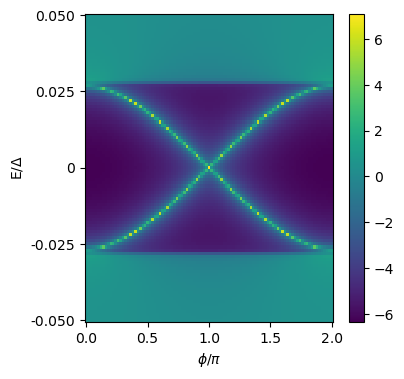

In [10]:
# ABS  Figure
sdsd=0.025
plt.figure(figsize=(4, 4))
X, Y = np.meshgrid(phi_plot, ef_plot)
plt.pcolormesh(X, Y, np.log(ABS), shading='auto')  # Added small epsilon to avoid log(0)
plt.colorbar(location='right')
plt.xlabel(r'$\phi$/$\pi$')

plt.ylabel('E/$\Delta$')
plt.yticks(
    [efmin, efmin/2, 0, efmax/2, efmax],
    [f"{efmin/delta:.3f}", f"{efmin/delta/2:.3f}", "0", f"{efmax/delta/2:.3f}", f"{efmax/delta:.3f}"]
)
plt.axis('square')
plt.axis('tight')
plt.show()

In [13]:
from joblib import Parallel, delayed
import numpy as np

# ==========================================
# 1. 封装单次计算任务 (强制传入 shumu 参数，避免全局变量失效)
# ==========================================
def compute_diode_task(shumu_val, m, B, a, uS_set, Delta, yshumu, A, H_q, H_l, T_21, T_LD, T_l, T_RD, T_r, N, KBT):
    # 打印验证信息
    print(f'进程运行中: n*2*np.pi*KBT/Delta = {shumu_val * 2 * np.pi * KBT / Delta}')
    
    # 为了绝对安全，我们跳过可能依赖全局变量的 J_of_phi，直接调用底层计算
    # 计算 phi/2 (即 0.5 * np.pi) 对应的右电极哈密顿量
    H_r_curr = H_onstie(m, B, a, uS_set, Delta, -0.5*np.pi, yshumu, 4, A)
    
    # 强制使用当前的 shumu_val 进行松原频率求和
    j_val = J_matsubara_sum(shumu_val, H_q, H_l, H_r_curr, T_21, T_LD, T_l, T_RD, T_r, N)
    
    return j_val

# ==========================================
# 2. 开启 2 核并行计算
# ==========================================
shumu_targets = [201, 202]
print(f"🚀 开始 2 核并行计算二极管收敛因子...")

# Parallel 会把 201 交给核心 A，把 202 交给核心 B，两者同时运行
results = Parallel(n_jobs=2)(
    delayed(compute_diode_task)(
        s, m, B, a, uS_set, Delta, yshumu, A, 
        H_q, H_l, T_21, T_LD, T_l, T_RD, T_r, N, KBT
    ) for s in shumu_targets
)

# ==========================================
# 3. 提取结果并计算因子差
# ==========================================
jjalpi = results[0]  # 对应 shumu=201 的结果
jjalpi2 = results[1] # 对应 shumu=202 的结果

print(f'\nshumu=201 时，J(phi/2)= {jjalpi}')
print(f'shumu=202 时，J(phi/2)= {jjalpi2}')

# 计算误差因子
alnalkna = abs(abs(jjalpi2) - abs(jjalpi)) / (abs(jjalpi2) + abs(jjalpi))
print('因子差=', alnalkna)

# 恢复默认的截断数供后续程序使用
shumu = 101

🚀 开始 2 核并行计算二极管收敛因子...

shumu=201 时，J(phi/2)= 0.004040778995188132
shumu=202 时，J(phi/2)= 0.004043647058639149
因子差= 0.0003547640156421143


In [14]:
from joblib import Parallel, delayed
from tqdm import tqdm

# ==========================================
# 1. 定义单点计算任务 (封装循环内部逻辑)
# ==========================================
def compute_single_J(phi, m, B, a, uS_set, Delta, yshumu, A, shumu, H_q, H_l, T_21, T_LD, T_l, T_RD, T_r, N):
    # 构建当前 phi 下的右电极哈密顿量
    # 注意：这里使用了 -phi 匹配你原始代码逻辑
    H_r_curr = H_onstie(m, B, a, uS_set, Delta, -phi, yshumu, 4, A)
    
    # 执行松原频率求和计算电流
    Jphi = J_matsubara_sum(shumu, H_q, H_l, H_r_curr, T_21, T_LD, T_l, T_RD, T_r, N)
    
    return Jphi

# ==========================================
# 2. 多线程(多进程)执行区
# ==========================================
# 设定相位列表
phi_list = np.linspace(0, 2*np.pi, 21)

# 针对你的 i7-13650HX (20线程)，建议使用 14 个核心
num_cores = 14 

print(f"🚀 开始并行计算 J vs phi，核心数: {num_cores}")

# Parallel 会自动分发 phi_list 中的每一个值到不同的 CPU 核心
J_list = Parallel(n_jobs=num_cores)(
    delayed(compute_single_J)(
        phi, m, B, a, uS_set, Delta, yshumu, A, 
        shumu, H_q, H_l, T_21, T_LD, T_l, T_RD, T_r, N
    ) for phi in tqdm(phi_list) # tqdm 显示进度条
)

# 转换为 numpy 数组方便后续处理
J_arr = np.array(J_list)

print("✅ 计算完成")

🚀 开始并行计算 J vs phi，核心数: 14


100%|██████████| 21/21 [00:00<00:00, 166.34it/s]


✅ 计算完成


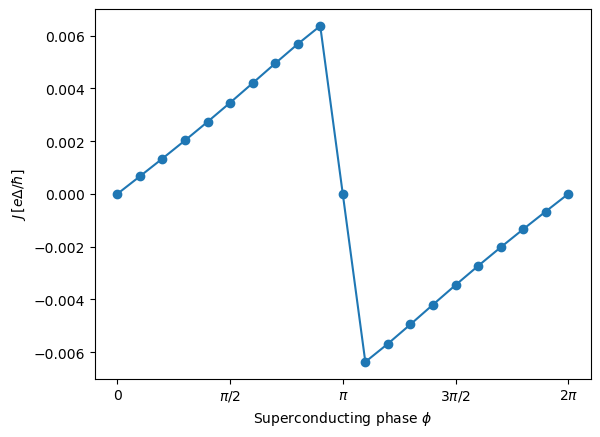

In [15]:
plt.figure()
plt.plot(phi_list, J_list, marker='o')
plt.xlabel(r'Superconducting phase $\phi$')
plt.ylabel(r'$J\,[e\Delta/\hbar]$')
plt.xticks(
    [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
    ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$']
)

plt.show()

In [16]:
from joblib import Parallel, delayed
from tqdm import tqdm

# ==========================================
# 1. 定义单点计算任务 (把原本循环里的逻辑搬进来)
# ==========================================
def compute_single_phi(phi, m, B, a, uS_set, Delta, yshumu, A, H_q, T_21, T_LD, T_l, T_RD, T_r, N, E_min, E_max, sdsd):
    # 构建当前 phi 下的哈密顿量
    H_r_curr = H_onstie(m, B, a, uS_set, Delta, -phi, yshumu, 4, A)
    
    # 定义局部目标函数
    def A_of_E_internal(E):
        G_00, _, _, _ = Gr_DD(
            H_q, H_l, H_r_curr,
            T_21, T_LD, T_l, T_RD, T_r,
            N, E
        )
        return bufeng(G_00)

    # 执行寻峰
    peak_energies = find_peaks_fmin(A_of_E_internal, E_min, E_max, N_guess=31, xtol=1e-6, ftol=1e-6)
    valid_peaks = [E for E in peak_energies if E < 0.0 and E > E_min]

    if len(valid_peaks) > 0:
        A_values = [A_of_E_internal(E) for E in valid_peaks]
        best_idx = np.argmax(A_values)
        return (phi, valid_peaks[best_idx]) # 返回 phi 和对应的最佳能量
    return None # 如果没找到峰则返回 None

In [18]:
# --- 1. 参数准备 ---
# 确保 phi_set 已经生成好

base_phi = phi_list # 这里假设你的 phi_list 已经设定好了 (比如 31 个点)
target_centers = np.sort(np.unique(base_phi))

dengchajuli=1e-3*1

# 为所有中心点配备左右辅助点 (+- 1e-4)
phi_with_buffers = np.concatenate([
    target_centers, 
    target_centers - dengchajuli, 
    target_centers + dengchajuli
])

phi_set = np.sort(np.unique(phi_with_buffers))
E_min, E_max = -delta * sdsd, 0 

# --- 2. 核心计算：并行执行 ---
num_cores = 14 # 针对你的 i7-13650HX 优化
print(f"🚀 开始多核并行寻峰，核心数: {num_cores}")

# Parallel 会自动把 phi_set 分成若干份交给不同的核心
results = Parallel(n_jobs=num_cores)(
    delayed(compute_single_phi)(
        phi, m, B, a, uS_set, Delta, yshumu, A, 
        H_q, T_21, T_LD, T_l, T_RD, T_r, N, 
        E_min, E_max, sdsd
    ) for phi in tqdm(phi_set) # tqdm 用于显示进度条
)

# --- 3. 结果收集与过滤 ---
# 过滤掉返回 None 的点，并提取数据
valid_results = [res for res in results if res is not None]
phi_list_1 = [res[0] for res in valid_results]
E_peak_list = [res[1] for res in valid_results]

phi_arr_full = np.array(phi_list_1)
E_arr_full = np.array(E_peak_list)

print(f"✅ 计算完成，共获得 {len(phi_arr_full)} 个有效数据点。")

🚀 开始多核并行寻峰，核心数: 14


100%|██████████| 63/63 [01:17<00:00,  1.24s/it]


✅ 计算完成，共获得 42 个有效数据点。


In [ ]:
# --- 3. 手动差分导数计算与数据提取 (带突变清洗与降级容错机制) ---
delta_phi = dengchajuli
energy_tolerance = 0.01  # 设置能量突变容忍度为 0.01

phi_final_list = []
E_final_list = []
dE_dphi_final_list = []

for p in target_centers:
    # 定位中心点及其左右辅助点
    idx_p = np.where(np.isclose(phi_arr_full, p, atol=1e-7))[0]
    idx_left = np.where(np.isclose(phi_arr_full, p - delta_phi, atol=1e-7))[0]
    idx_right = np.where(np.isclose(phi_arr_full, p + delta_phi, atol=1e-7))[0]
    
    # 只要中心点存在，我们就尝试去算它的导数
    if len(idx_p) > 0:
        E_p = E_arr_full[idx_p[0]]
        deriv = 0.0 # 默认导数
        
        # 提取辅助点能量（如果存在）
        E_left = E_arr_full[idx_left[0]] if len(idx_left) > 0 else None
        E_right = E_arr_full[idx_right[0]] if len(idx_right) > 0 else None
        
        # --- 核心清洗：检查能量突变 ---
        # 如果左右护法的能量和中心点偏差过大(>0.01)，则将它们视为无效点
        if E_left is not None and abs(E_left - E_p) > energy_tolerance:
            E_left = None
            
        if E_right is not None and abs(E_right - E_p) > energy_tolerance:
            E_right = None

        # --- 导数计算 (梯队降级) ---
        # 1. 理想情况：左右有效护法都在，使用高精度中心差分
        if E_left is not None and E_right is not None:
            deriv = (E_right - E_left) / (2 * delta_phi)
            
        # 2. 只有右边有效，使用前向差分
        elif E_right is not None:
            deriv = (E_right - E_p) / delta_phi
            
        # 3. 只有左边有效，使用后向差分
        elif E_left is not None:
            deriv = (E_p - E_left) / delta_phi
            
        # 4. 左右有效点都没了，导数只能记作 0
        else:
            print(f"警告: 相位 {p/np.pi:.3f}pi 处缺乏有效的辅助点(或突变过大)，导数设为 0")
            deriv = 0.0
            
        # 记录清洗后的数据
        phi_final_list.append(p)
        E_final_list.append(E_p)
        dE_dphi_final_list.append(deriv)

# 转换为 Numpy 数组
phi_final = np.array(phi_final_list)
E_final = np.array(E_final_list)
dE_dphi_final = np.array(dE_dphi_final_list)






#绘图ABS观察
plt.figure(figsize=(4, 4))
# 使用 r 前缀处理 label
plt.plot(phi_final, E_final, 'o-', color='tab:blue', markersize=4, label=r'Max Peak $E(\phi)$')

plt.xlabel(r"Superconducting phase $\phi$")
plt.ylabel(r"$E / \Delta$")
# 使用 fr 前缀处理带变量的 LaTeX 标题

plt.xlim(0, 2*np.pi)
#plt.ylim(E_min, 0.1)
plt.yticks([-delta*sdsd, -delta*sdsd/2, 0], [-1*sdsd, -1*sdsd/2, 0])
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi], ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
#plt.xlim(1.79*np.pi,1.81*np.pi)
#plt.ylim(-0.01,0.01)
plt.show()

# --- 5. 绘图：导数图 ---
plt.figure(figsize=(4, 4)) 
plt.plot(phi_final, dE_dphi_final, 's-', color='tab:red', markersize=4, label=r'$\partial E / \partial \phi$')

# 使用 fr 处理 axvline 的标签

plt.xlabel(r"Phase $\phi$")
plt.ylabel(r"Derivative $\partial E / \partial \phi$")

# 使用 fr 格式化大标题，避免转义错误

plt.xlim(0, 2*np.pi)
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi], ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
#plt.ylim(-0.02,0.06)
plt.show()